In [74]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
import scipy.interpolate as interp 
try:
    import cupy as xp
    import cupyx.scipy.interpolate as xinterp
    # print("has cupy")
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
    import scipy.interpolate as xinterp  
    # print("no cupy")

from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import FDTDIResponseGenerator
from Triangle_BBH.Utils import Likelihood, Fstatistics
from Triangle_BBH.Fisher import *

# import multiprocessing
# if __name__=='__main__':
#     multiprocessing.set_start_method("fork")
    
import bilby 

# np.random.seed(114514)
# xp.random.seed(114514)

In [ ]:
class WaveformGeneratorNew():
    def __init__(self, mode='full'):
        """ 
            vectorized wrapper of the PhenomHM waveform 
            using the Fourier transformation convension of S. Marsat
            h_lm(f) = A_lm(f) exp[i Phi_lm(f)]
            t_lm(f) = d Phi_lm(f) / df / 2PI
            with Phi_lm(f) being -Psi_lm(f) in the paper
            
            mode = 'full': HM waveform
            mode = 'primary': D waveform
        """
        self.waveform = WF.IMRPhenomHM(mode=mode)
    
    def __call__(self, parameters, Nfreqs=1024, fmin=1e-5, fmax=1e-1, freqs=None):
        """  
            parameters = {
                "name" : numpy array of shape (Nevents),
                ...
            }
            the parameters include:
            "chirp_mass" [MSUN], "mass_ratio" [1], "spin_1z" [1], "spin_2z" [1], 
            "coalescence_time" [DAY] (SSB), "coalescence_phase" [rad],
            "luminosity_distance" [MPC], "inclination" [rad], 
            "longitude" [rad], "latitude" [rad], "psi" [rad]
            11 parameters in total
            *** NOTE that coalescence time has to be converted to tc at the SSB origin.
            *** NOTE that coalescence phase parameter is ignored and set to 0
            freqs should be None or numpy array of shape (Nevents, Nfreqs)
            
            Calculate the mode-independent frequency grids of shape (Nevents, Nfreqs), 
            and mode-dependent (Nevents, Nfreqs) arrays of GW amplitudes, phases and t-f relationships, 
            stored in dictionaries with the keys being mode numbers.
            e.g. amps_out = {
                (l, m) : (Nevents, Nfreqs) array,
                ...
            }
        """
        Nevents = np.atleast_1d(parameters["chirp_mass"]).shape[0]
        event_idx = np.arange(Nevents)
        
        # conversion of parameters
        parameters_in = {}
        parameters_in["Mc"] = np.atleast_1d(parameters["chirp_mass"])
        parameters_in["eta"] = np.atleast_1d(eta_q(parameters["mass_ratio"]))
        parameters_in["chi1z"] = np.atleast_1d(parameters["spin_1z"])
        parameters_in["chi2z"] = np.atleast_1d(parameters["spin_2z"])
        parameters_in["dL"] = np.atleast_1d(parameters["luminosity_distance"] / 1e3) 
        parameters_in['coalescence_time'] = np.atleast_1d(parameters['coalescence_time'])
        
        # calculate frequency grids of shape (Nfreqs, Nevents) (will be transposed later), independent of modes
        # NOTE: for later convenience fgrid must be the same for all events
        if type(freqs) == np.ndarray:
            if freqs.shape[0] == Nevents:
                fgrids = np.transpose(freqs) # (Nfreqs, Nevents)
            else: 
                fgrids = np.transpose(np.tile(freqs, (Nevents, 1))) # (Nevents, Nfreqs) -> (Nfreqs, Nevents)
        else:
            # self.fcutarr = self.waveform.fcut(**parameters_in) 
            # fmaxarr = np.full(fcutarr.shape, min(np.min(fcutarr), fmax))
            # fminarr = np.full(fcutarr.shape, fmin)
            
            fminarr = np.full(Nevents, fmin)
            fmaxarr = np.full(Nevents, fmax)
            fgrids = np.geomspace(fminarr, fmaxarr, num=int(Nfreqs)) # (Nfreqs, Nevents)
            
        self.fcutarr = self.waveform.fcut(**parameters_in) # (Nevents) TEST 
        FSTEP = 1e-6 # TEST 
        self.fcutarr = self.fcutarr - FSTEP # TEST 
        fgrids_cut = np.array([
            self.fcutarr - FSTEP, 
            self.fcutarr
        ]) # (2, Nevents) TEST 
        
        # calculate amplitudes, phases by modes, each mode is originally a (Nfreqs, Nevents) array (will be transposed)
        amplitudes = self.waveform.Ampl(fgrids, **parameters_in) # dict
        phases = self.waveform.Phi(fgrids, **parameters_in) # dict
        phases_cut = self.waveform.Phi(fgrids_cut, **parameters_in) # dict, each mode of shape (2, Nevents) TEST 
        
        # adjust keys to [(2,2), (2, 1), (3, 2), (3, 3), (4, 3), (4, 4)] and shapes to (Nevents, Nfreqs)
        amps_out = {}
        phas_out = {}
        phas_out_cut = {} # TEST 
        for k, v in amplitudes.items():
            amps_out[(int(k[0]), int(k[1]))] = v.T # (Nevents, Nfreqs)
            phas_out[(int(k[0]), int(k[1]))] = phases[k].T # (Nevents, Nfreqs)
            phas_out_cut[(int(k[0]), int(k[1]))] = phases_cut[k].T # (Nevents, 2) # TEST 
        fgrids = fgrids.T # (Nevents, Nfreqs)
        
        dphase_22_cut = (phas_out_cut[(2,2)][:, 1] - phas_out_cut[(2,2)][:, 0]) / FSTEP # phase derivative (Nevents) TEST 
        # phase_mode_correction1  = -dphase_22_cut[:, np.newaxis] * (fgrids - self.fcutarr[:, np.newaxis]) # (Nevents, Nfreqs) TEST 
        # phase_mode_correction1 += (TWOPI * parameters_in['coalescence_time'] * DAY)[:, np.newaxis] * fgrids # correction due to tc (Nevents, Nfreqs) TEST 
        phase_mode_correction1 = (-dphase_22_cut + TWOPI * parameters_in['coalescence_time'] * DAY)[:, np.newaxis] * (fgrids - self.fcutarr[:, np.newaxis]) # (Nevents, Nfreqs) TEST
        phase_22_cut = np.array([np.interp(x=self.fcutarr[ievent], xp=fgrids[ievent], fp=phas_out[(2,2)][ievent]) for ievent in range(Nevents)]) # (Nevents), TEST 
        for k, v in phas_out.items(): 
            phase_mode_correction2 = -0.5 * k[1] * phase_22_cut # -m/2 * phi_cut_22 (Nevents) TEST 
            phas_out[k] = v + phase_mode_correction1 + phase_mode_correction2[:, np.newaxis] # (Nevents, Nfreqs)
        
        # # set t_ref = 0, phi_ref = 0 
        # ind_ref = np.argmax(fgrids ** 2 * amps_out[(2, 2)], axis=1) # (Nevents)
        # f_ref = fgrids[event_idx, ind_ref] # (Nevents)
        # f_ref_1 = fgrids[event_idx, ind_ref - 1]
        # phase_22_ref = phas_out[(2, 2)][event_idx, ind_ref] # (Nevents)
        # phase_22_ref_1 = phas_out[(2, 2)][event_idx, ind_ref - 1]
        # dphase_22_ref = (phase_22_ref - phase_22_ref_1) / (f_ref - f_ref_1) # (Nevents)
        # phase_correct1 = -(fgrids - f_ref[:, np.newaxis]) * dphase_22_ref[:, np.newaxis] # correct t_ref = 0, i.e. d Phi / df @ f_ref = 0
        # # add the extra contribution of coalescence time 
        # phase_correct1 += TWOPI * fgrids * parameters_in['coalescence_time'][:, np.newaxis] * DAY 
        # for k, v in phas_out.items():
        #     phase_correct2 = -k[1] * 0.5 * phase_22_ref # correct phi_ref
        #     phas_out[k] = v + phase_correct1 + phase_correct2[:, np.newaxis]
        
        # calculate time grids by t-f relationship 
        tfs_out = {}
        # dfgrids = fgrids[:, 1:] - fgrids[:, :-1]
        # for k, v in phas_out.items():
        #     tfs_out[k] = np.zeros_like(v) # (Nevents, Nfreqs)
        #     dphase = v[:, 1:] - v[:, :-1]
        #     tfs_out[k][:, :-1] = dphase / dfgrids / TWOPI 
        #     tfs_out[k][:, -1] = tfs_out[k][:, -2] # fill the last frequency
        dfgrids = np.gradient(fgrids, axis=1) # (Nevents, Nfreqs) TEST 
        for k, v in phas_out.items(): 
            dphase = np.gradient(v, axis=1) # (Nevents, Nfreqs) TEST 
            tfs_out[k] = dphase / dfgrids / TWOPI # (Nevents, Nfreqs) TEST 
            
        # # TEST 
        # self.fgrids_cut = fgrids_cut 
        # self.phase_cut = phas_out_cut 
 
        return fgrids, amps_out, phas_out, tfs_out # each item of shape (Nevents, Nfreqs)

In [76]:
t_start = 200. * DAY # start time in s
Tobs = 30. * DAY # data length in s 
t_end = t_start + Tobs # end time in s 
dt = 1. # time cadance in s 
fsample = 1. / dt # sampling rate in Hz 
data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
delta_f = 1. / Tobs

# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
# for i in range(1, 50): 
#     mask_idx = np.where(np.abs(data_frequencies_full - i*0.025)<i*3e-4)[0]
#     mask[mask_idx] = False 

# remove the frequencies below Taiji sensitive band 
mask_idx = np.where(data_frequencies_full < 1e-5)[0]
mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]

data_frequencies.shape, data_frequencies_full.shape 

((1295975,), (1296001,))

In [77]:
# the path of Taiji orbit 
orbit = Orbit(
    OrbitDir="../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB", 
    dt=DAY, 
    ) 

# initialize  waveform generator 
WFG = WaveformGenerator(
    mode="primary", 
)

WFGnew = WaveformGeneratorNew(
    mode="primary", 
)

# initialize response generator 
FDTDI = FDTDIResponseGenerator(
    orbit_class=orbit, 
    waveform_generator=WFG, 
)

# response settings 
response_kwargs = dict(
    fmin=1e-5, # used to calculate freq grid
    fmax=1, # used to calculate freq grid
    Nfreqs=1024, # used to calculate freq grid
    modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tc_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    output_by_mode=False, 
    interpolation_method='cubic',
)

In [78]:
lgMc_prior = [5.5, 6.5]
q_prior = [0.1, 1]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tc_prior = [(t_start + 0.5 * Tobs) / DAY, (t_end - 0.1 * Tobs) / DAY] # ensure the inclusion of long enough GW waveform 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

lgdl_prior = [4., 5.]

intrinsic_param_priors

array([[ 5.50000000e+00,  6.50000000e+00],
       [ 1.00000000e-01,  1.00000000e+00],
       [-9.00000000e-01,  9.00000000e-01],
       [-9.00000000e-01,  9.00000000e-01],
       [ 2.15000000e+02,  2.27000000e+02],
       [ 0.00000000e+00,  6.28318531e+00],
       [-1.00000000e+00,  1.00000000e+00]])

In [79]:
# generate source parameter and clean signal 
mbhb_parameters = {
    'chirp_mass': np.power(10., np.random.uniform(lgMc_prior[0], lgMc_prior[1])), 
    'mass_ratio': np.random.uniform(q_prior[0], q_prior[1]), 
    'spin_1z': np.random.uniform(s1_prior[0], s1_prior[1]),
    'spin_2z': np.random.uniform(s2_prior[0], s2_prior[1]),
    'coalescence_time': np.random.uniform(tc_prior[0], tc_prior[1]), 
    'coalescence_phase': np.random.uniform(0, TWOPI),
    'luminosity_distance': np.power(10., np.random.uniform(lgdl_prior[0], lgdl_prior[1])), 
    'inclination': np.arccos(np.random.uniform(-1., 1.)), # [rad]
    'longitude': np.random.uniform(lam_prior[0], lam_prior[1]), # [rad]
    'latitude': np.arcsin(np.random.uniform(sinbeta_prior[0], sinbeta_prior[1])), # [rad]
    'psi': np.random.uniform(0, PI) # [rad]
    }
mbhb_parameters

{'chirp_mass': 2277803.231212457,
 'mass_ratio': 0.9743896860312834,
 'spin_1z': -0.12452844421661158,
 'spin_2z': -0.11897382117258937,
 'coalescence_time': 220.77630799662708,
 'coalescence_phase': 2.6614980759544076,
 'luminosity_distance': 19486.456236400572,
 'inclination': 2.474882080966239,
 'longitude': 4.700512758607113,
 'latitude': -0.03921450877957418,
 'psi': 0.061856161253662875}

In [80]:
# wf_channels = FDTDI.Response(
#     mbhb_parameters, 
#     data_frequencies, 
#     **response_kwargs
#     )
# wf_channels.shape 

In [81]:
wf_parameters = mbhb_parameters.copy()
wf_parameters["coalescence_time"] = 0. 

fgrids, amps_out, phas_out, tfs_out = WFG(
    parameters=wf_parameters, 
    freqs=data_frequencies, 
)

fgrids_new, amps_out_new, phas_out_new, tfs_out_new = WFGnew(
    parameters=wf_parameters, 
    freqs=data_frequencies, 
)

fcut = WFGnew.fcutarr[0]

(1e-25, 1e-15)

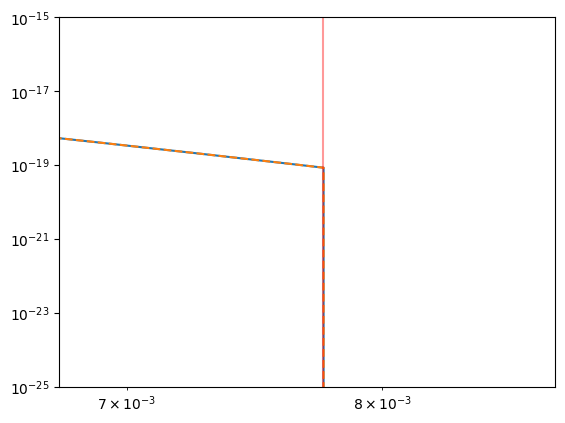

In [82]:
plt.loglog(fgrids[0], amps_out[(2,2)][0])
plt.loglog(fgrids_new[0], amps_out_new[(2,2)][0], linestyle="--")
plt.vlines(fcut, 1e-25, 1e-12, color="r", alpha=0.4)
plt.xlim(fcut - 1e-3, fcut + 1e-3)
plt.ylim(1e-25, 1e-15)

In [83]:
WFGnew.fcutarr, WFGnew.fgrids_cut, WFGnew.phase_cut[(2,2)]

(array([0.00775762]),
 array([[0.00775662],
        [0.00775762]]),
 array([[ 0.00000000e+00, -4.35522073e-05]]))

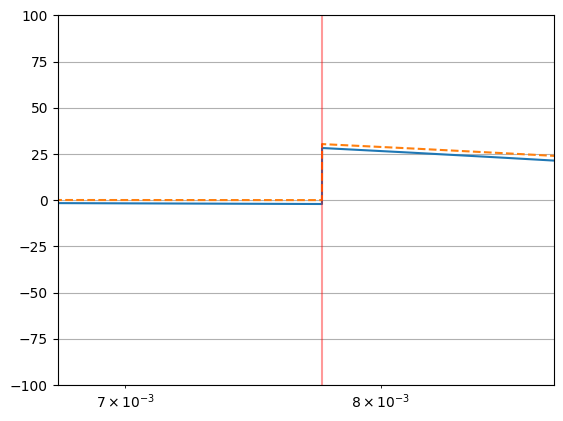

In [84]:
plt.semilogx(fgrids[0], phas_out[(2,2)][0])
plt.semilogx(fgrids_new[0], phas_out_new[(2,2)][0], linestyle="--")
plt.vlines(fcut, -100, 100, color="r", alpha=0.4)
plt.xlim(fcut - 1e-3, fcut + 1e-3)
plt.ylim(-100, 100)
plt.grid()

/var/folders/_f/d29qj88911xdzjc9ffs55hph0000gn/T/ipykernel_75237/2456810090.py:3: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(fcut - 5e-2, fcut + 1e-2)


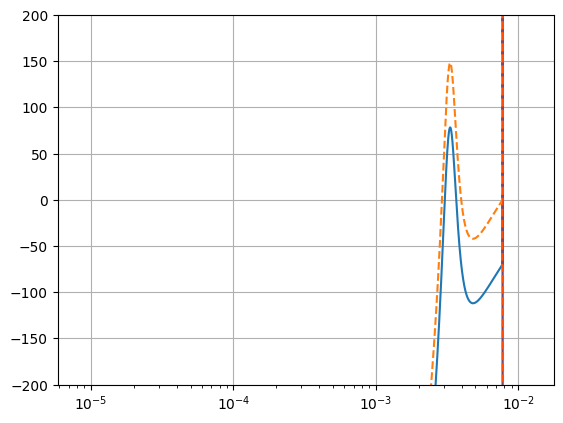

In [85]:
plt.semilogx(fgrids[0], tfs_out[(2,2)][0])
plt.semilogx(fgrids_new[0], tfs_out_new[(2,2)][0], linestyle="--")
plt.xlim(fcut - 5e-2, fcut + 1e-2)
plt.ylim(-200, 200)
plt.vlines(fcut, -200, 200, color="r", alpha=0.4)
plt.grid()